Used Car Price Prediction: Karachi Market

Stage 0: Problem Framing

Questions to ask myself before any code:

- What exactly am I predicting? (name the column)
- Regression or classification, and why?
- Who/what would use this, and how would a wrong prediction hurt?
- What does "good" look like here, which metric, and why that one?
- What's the scope of this data? What should this model NOT be trusted to generalize to?

Stage 0: Problem Framing, Answers

- Target: Predicting `listingPrice` for used cars.
- Problem type: Regression.
- Audience / cost of being wrong: A prospective buyer deciding whether an asking price is fair. A wrong prediction could cost them financially, overpaying for a car that's actually overpriced for its specs.
- Metric: RMSE, reported alongside MAE. RMSE is in the same units as price (PKR) and penalizes large misses more heavily, but that outlier-sensitivity only makes sense once Stage 2 cleaning is done, otherwise a single bad listing can distort it.
- Scope, what this model should NOT be trusted for:
  - Other cities. Every row in this dataset is a Karachi listing (confirmed via the `name` field), the model has seen zero data from Lahore, Islamabad, or anywhere else, and different cities/provinces can have different registration/tax regimes and demand patterns. No evidence exists either way for those markets.
  - Long time horizons. This is a snapshot of Karachi asking prices as of ~December 2025 (per the filename). Used car prices move with currency devaluation, fuel prices, and import policy, so this model's accuracy should be expected to decay without retraining on fresher data.
  - Actual sale price. `listingPrice` is the seller's asking price, not a confirmed transaction price. In a market where haggling is normal, the model is really predicting "what a seller would list this car for," not "what it will sell for."


Stage 1: Data Loading & Structural Inspection

First instinct: check the data is mechanically sound. Don't analyze meaning yet.

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('used_car_listings_13_12_2025.csv')

In [3]:
df.head()

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
0,2013.0,Toyota,Hybrid,Toyota Prius 2013 for sale in Karachi,Automatic,1800cc,"156,000 km",4125000.0,Prius,12.0
1,2008.0,Toyota,Petrol,Toyota Vitz 2008 for sale in Karachi,Automatic,1000cc,"85,000 km",2080000.0,Vitz,17.0
2,2022.0,Daihatsu,Petrol,Daihatsu Mira 2022 for sale in Karachi,Automatic,660cc,"16,000 km",3575000.0,Mira,3.0
3,2022.0,Toyota,Petrol,Toyota Passo 2022 for sale in Karachi,Automatic,1000cc,"68,000 km",3990000.0,Passo,3.0
4,2013.0,Honda,Hybrid,Honda Insight 2013 for sale in Karachi,Automatic,1300cc,"78,000 km",2890000.0,Insight,12.0


In [4]:
df.describe()

,year,listingPrice,age
count,15171.000000,1.517100e+04,15171.000000
mean,2014.120823,5.271934e+06,10.879177
std,8.798385,8.277969e+06,8.798385
min,1951.000000,1.040000e+05,0.000000
25%,2009.000000,1.600000e+06,4.000000
50%,2017.000000,3.200000e+06,8.000000
75%,2021.000000,5.650000e+06,16.000000
max,2025.000000,1.450000e+08,74.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          15171 non-null  float64
 1   manufacturer  15171 non-null  str    
 2   fuelType      15171 non-null  str    
 3   name          15171 non-null  str    
 4   transmission  15171 non-null  str    
 5   engine        15171 non-null  str    
 6   mileage       15171 non-null  str    
 7   listingPrice  15171 non-null  float64
 8   variant       15171 non-null  str    
 9   age           15171 non-null  float64
dtypes: float64(3), str(7)
memory usage: 1.2 MB


Duplicates: exact
Every column identical. Found via `df.duplicated()`.

In [6]:
df.duplicated().sum()

np.int64(2477)

In [7]:
df[df.duplicated(keep=False)].sort_values(by=['manufacturer','variant','year','mileage']).head(20)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
1935,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
2017,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
4840,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
4958,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
3843,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
3901,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
4630,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0
4641,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0
263,2014.0,Audi,Petrol,Audi A4 2014 for sale in Karachi,Automatic,1800cc,"48,000 km",6500000.0,A4,11.0
312,2014.0,Audi,Petrol,Audi A4 2014 for sale in Karachi,Automatic,1800cc,"48,000 km",6500000.0,A4,11.0


Duplicates: near
Same manufacturer/variant/year/engine/fuelType/transmission, but mileage/price may differ, could be the same car re-listed, or just a popular config shared by different cars.

In [8]:
df[df.duplicated(subset=['manufacturer','variant','year','engine','fuelType','transmission'], keep=False)].sort_values(by=['manufacturer','variant','year','engine','fuelType','transmission']).head(20)

,year,manufacturer,fuelType,name,transmission,engine,mileage,listingPrice,variant,age
2175,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"101,000 km",5950000.0,A3,9.0
2302,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"41,000 km",6700000.0,A3,9.0
9914,2016.0,Audi,Petrol,Audi A3 2016 for sale in Karachi,Automatic,1200cc,"62,000 km",5850000.0,A3,9.0
1935,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
2017,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"45,812 km",8500000.0,A3,7.0
4840,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
4958,2018.0,Audi,Petrol,Audi A3 2018 for sale in Karachi,Automatic,1200cc,"92,000 km",6535000.0,A3,7.0
3843,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
3901,2019.0,Audi,Petrol,Audi A3 2019 for sale in Karachi,Automatic,1200cc,"43,359 km",6900000.0,A3,6.0
4630,2012.0,Audi,Petrol,Audi A4 2012 for sale in Karachi,Automatic,1800cc,"39,785 km",7500000.0,A4,13.0


Stage 2: Data Cleaning

Fix what's structurally broken. No new features yet, no analysis conclusions yet, just correctness.

In [9]:
df_clean = df.drop_duplicates(keep='first')

In [10]:
df_clean.shape

(12694, 10)

In [11]:
df_clean['mileage'] = df_clean['mileage'].str.replace(',', '').str.replace(' km', '').astype(int)

df_clean['engine'] = df_clean['engine'].str.replace('cc', '')
df_clean.loc[df_clean['engine'] == '', 'engine'] = '0'
df_clean['engine'] = df_clean['engine'].astype(int)

Investigating mileage spread within near-duplicate groups
Still just inspecting, no decision applied yet. `count` alone doesn't mean duplicate (a popular new model naturally has many genuinely different, low-mileage listings); `range` tells you how spread out a group's mileage is.

In [12]:
df_clean.groupby(['manufacturer', 'variant', 'year', 'engine', 'fuelType', 'transmission'])['mileage'].agg(['count', 'min', 'max'])

count     min  \
manufacturer variant year   engine fuelType transmission                  
Adam         Revo    2006.0 800    Petrol   Manual            1   50000   
Audi         A3      2015.0 1200   Petrol   Automatic         1   80000   
                     2016.0 1200   Petrol   Automatic         3   41000   
                     2018.0 1200   Petrol   Automatic         2   45812   
                     2019.0 1200   Petrol   Automatic         1   43359   
...                                                         ...     ...   
Volkswagen   Beetle  1971.0 1300   Petrol   Manual            1   97823   
                            1600   Petrol   Manual            1  120000   
                     1974.0 1200   Petrol   Manual            1     250   
             Up      2012.0 1000   Petrol   Automatic         1   78000   
Willys       M38     1952.0 3300   Diesel   Manual            1   30000   

                                                             max  
manufacturer variant year   engine fuelType transmission          
Adam         Revo    2006.0 800    Petrol   Manual         50000  
Audi         A3      2015.0 1200   Petrol   Automatic      80000  
                     2016.0 1200   Petrol   Automatic     101000  
                     2018.0 1200   Petrol   Automatic      92000  
                     2019.0 1200   Petrol   Automatic      43359  
...                                                          ...  
Volkswagen   Beetle  1971.0 1300   Petrol   Manual         97823  
                            1600   Petrol   Manual        120000  
                     1974.0 1200   Petrol   Manual           250  
             Up      2012.0 1000   Petrol   Automatic      78000  
Willys       M38     1952.0 3300   Diesel   Manual         30000  

[2598 rows x 3 columns]

In [13]:
summary = df_clean.groupby(['manufacturer', 'variant', 'year', 'engine', 'fuelType', 'transmission'])['mileage'].agg(['count', 'min', 'max'])
summary['range'] = summary['max'] - summary['min']
summary['range']

manufacturer  variant  year    engine  fuelType  transmission
Adam          Revo     2006.0  800     Petrol    Manual              0
Audi          A3       2015.0  1200    Petrol    Automatic           0
                       2016.0  1200    Petrol    Automatic       60000
                       2018.0  1200    Petrol    Automatic       46188
                       2019.0  1200    Petrol    Automatic           0
                                                                 ...  
Volkswagen    Beetle   1971.0  1300    Petrol    Manual              0
                               1600    Petrol    Manual              0
                       1974.0  1200    Petrol    Manual              0
              Up       2012.0  1000    Petrol    Automatic           0
Willys        M38      1952.0  3300    Diesel    Manual              0
Name: range, Length: 2598, dtype: int64

In [14]:
multi = summary[summary['count'] > 1]
multi

count    min  \
manufacturer variant     year   engine fuelType transmission                 
Audi         A3          2016.0 1200   Petrol   Automatic         3  41000   
                         2018.0 1200   Petrol   Automatic         2  45812   
             A4          2014.0 1800   Petrol   Automatic         3  48000   
                         2016.0 1400   Petrol   Automatic         2  48000   
                         2017.0 1400   Petrol   Automatic         2  72000   
...                                                             ...    ...   
Toyota       Yaris Sedan 2024.0 1300   Petrol   Automatic         8   1700   
                                1500   Petrol   Automatic         2   7800   
                         2025.0 1300   Petrol   Automatic        28      5   
                                                Manual            3     69   
United       Bravo       2021.0 800    Petrol   Manual            2  30000   

                                                                 max  range  
manufacturer variant     year   engine fuelType transmission                 
Audi         A3          2016.0 1200   Petrol   Automatic     101000  60000  
                         2018.0 1200   Petrol   Automatic      92000  46188  
             A4          2014.0 1800   Petrol   Automatic      52155   4155  
                         2016.0 1400   Petrol   Automatic      62500  14500  
                         2017.0 1400   Petrol   Automatic      81000   9000  
...                                                              ...    ...  
Toyota       Yaris Sedan 2024.0 1300   Petrol   Automatic      27000  25300  
                                1500   Petrol   Automatic      24342  16542  
                         2025.0 1300   Petrol   Automatic      10000   9995  
                                                Manual          5100   5031  
United       Bravo       2021.0 800    Petrol   Manual         74000  44000  

[1330 rows x 4 columns]

Decision: final near-duplicate rule

Group-level `range` has a blind spot for groups of 3+ (a tight real pair can hide inside a wider, mostly-legitimate group, see the Audi A4 2014 case in `project/notes/NOTES.md`). Rather than chase that further, the rule used here: treat rows as the same car only if they match on every spec and `listingPrice` exactly. Known limitation (documented, not solved): this doesn't separately verify mileage closeness, so it could rarely over- or under-merge (e.g. two identically-priced new cars from the same dealer).

In [15]:
df_final = df_clean.drop_duplicates(
    subset=['manufacturer','variant','year','engine','fuelType','transmission','listingPrice'],
    keep='last'
)
df_final.shape

(10250, 10)

`age` vs `year`: dropping the redundant one

`age` is a fixed transform of `year` (found via `.describe()`, identical standard deviations to six decimals). Keeping both would feed the model the same information twice (multicollinearity). Keeping `year`, dropping `age`.

In [16]:
df_final = df_final.drop(columns=['age'])
df_final.info()

<class 'pandas.DataFrame'>
Index: 10250 entries, 0 to 15170
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          10250 non-null  float64
 1   manufacturer  10250 non-null  str    
 2   fuelType      10250 non-null  str    
 3   name          10250 non-null  str    
 4   transmission  10250 non-null  str    
 5   engine        10250 non-null  int64  
 6   mileage       10250 non-null  int64  
 7   listingPrice  10250 non-null  float64
 8   variant       10250 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 800.8 KB


Removing invalid mileage values found during Stage 3 EDA

While plotting mileage's distribution below (Stage 3), sorting by mileage turned up two separate problems: thirteen rows sharing the exact placeholder value 1,000,000 km, plus a handful of near-identical values (999999, 999998, 999990, 999000) that are almost certainly the same placeholder with slightly different rounding. Beyond that cluster, some remaining rows have mileage that is far too high for the car's age, for example a 2018 Suzuki Swift showing 980,000 km, about 140,000 km per year, which is not physically plausible. Full reasoning and the rows that led here are in `project/notes/NOTES.md`.

In [17]:
# Remove the placeholder cluster sitting right at the ceiling (1,000,000 and near-identical values)
df_final = df_final[df_final['mileage'] < 999000]

# Remove remaining rows where mileage is implausible for the car's age
reference_year = 2025
age_years = (reference_year - df_final['year']).clip(lower=1)
implied_km_per_year = df_final['mileage'] / age_years

df_final = df_final[implied_km_per_year <= 50000]
df_final.shape

(10173, 9)

Removing invalid engine values found during Stage 3 EDA

Sorting by engine size (below, Stage 3) surfaced a placeholder cluster (three unrelated cars, a Suzuki Vitara, a Honda Civic, and a Toyota Land Cruiser, all sharing the identical, impossible `15000`), plus several individual values too large for what the car actually is (a Daihatsu Move, a kei car legally capped at 660cc, showing `6600`, likely a stray extra zero; a Toyota IST, Mitsubishi Pajero, Toyota Crown, and Suzuki Alto each showing implausibly large values). Separately, a cluster of Mercedes-Benz C-Class and S-Class listings share engine sizes around 6200 to 6203cc, which is a real spec for their AMG performance variants, not a placeholder, since it repeats consistently across the same model across different years rather than across unrelated car types. Full reasoning is in `project/notes/NOTES.md`.

In [18]:
# 6500 sits in the gap between the highest genuine value found (Mercedes AMG variants, ~6200-6203cc)
# and the lowest confirmed error (Daihatsu Move at 6600cc, impossible for a 660cc-capped kei car)
df_final = df_final[df_final['engine'] <= 6500]
df_final.shape

(10164, 9)

Removing inconsistent fuelType casing found during Stage 3 EDA

While building a boxplot of listingPrice grouped by fuelType (below, Stage 3 Bivariate), df_final['fuelType'].unique() showed 8 categories instead of the expected 7: LPG and Lpg are the same fuel type, just typed inconsistently, splitting one real category into two thinner ones. Every other value (CNG, PHEV, Petrol, Diesel, Hybrid, Electric) was already consistently formatted, so rather than blanket-transforming the whole column with .str.upper() (which would flatten the already-correct word-case values into shouting case), only the one broken value is fixed directly.

In [19]:
df_final['fuelType'] = df_final['fuelType'].replace('Lpg', 'LPG')

`name` vs manufacturer + variant + year: dropping the redundant one, found during Stage 3 EDA

While deciding how to handle the high-cardinality categorical columns (below, Stage 3 Bivariate), df_final['name'].nunique() came back as 1749, unusually high, and looking at a sample showed a clear pattern: every value is just "{manufacturer} {variant} {year} for sale in Karachi", for example "Toyota Prius 2013 for sale in Karachi". The "for sale in Karachi" suffix carries no information since this entire dataset is Karachi listings.

Verified this by reconstructing the expected string from manufacturer, variant, and year and comparing it to the actual name column: 10,050 out of the full row count matched exactly. The small number of mismatches (about 200 rows) were checked directly and turned out to be a naming quirk specific to Mercedes-Benz rows, where variant already includes the word "Benz" (e.g. variant "Benz C Class" with manufacturer "Mercedes Benz"), so the naive reconstruction doubled it ("Mercedes Benz Benz C Class") while the real name field only says it once. Not new information, just an artifact of the reconstruction method.

This is the same situation as `age` vs `year` earlier in this section: name is a fixed transform of columns that already exist (manufacturer, variant, year), so it is dropped entirely rather than treated as a genuine high-cardinality feature to encode.

In [20]:
print(df_final['name'].nunique())

1749


In [21]:
df_final['name'].head(10)

0            Toyota Prius 2013 for sale in Karachi
1             Toyota Vitz 2008 for sale in Karachi
3            Toyota Passo 2022 for sale in Karachi
4           Honda Insight 2013 for sale in Karachi
5     Toyota Land Cruiser 2023 for sale in Karachi
6          Toyota Harrier 2020 for sale in Karachi
7            Toyota Prius 2024 for sale in Karachi
8            Toyota Hilux 2022 for sale in Karachi
10            Honda Civic 2022 for sale in Karachi
12        Lexus RX Series 2011 for sale in Karachi
Name: name, dtype: str

In [22]:
reconstructed = df_final['manufacturer'] + ' ' + df_final['variant'] + ' ' + df_final['year'].astype(int).astype(str) + ' for sale in Karachi'
(reconstructed == df_final['name']).sum()

np.int64(10050)

In [23]:
mismatches = df_final[reconstructed != df_final['name']]
mismatches[['manufacturer', 'variant', 'year', 'name']].head(10)

,manufacturer,variant,year,name
16,Mercedes Benz,Benz SLK Class,2004.0,Mercedes Benz SLK Class 2004 for sale in Karachi
118,Mercedes Benz,Benz C Class,2010.0,Mercedes Benz C Class 2010 for sale in Karachi
233,Mercedes Benz,Benz E Class,2004.0,Mercedes Benz E Class 2004 for sale in Karachi
262,Mercedes Benz,Benz C Class,2018.0,Mercedes Benz C Class 2018 for sale in Karachi
779,Mercedes Benz,Benz C Class,2020.0,Mercedes Benz C Class 2020 for sale in Karachi
784,Mercedes Benz,Benz C Class,2020.0,Mercedes Benz C Class 2020 for sale in Karachi
902,Mercedes Benz,Benz E Class,2015.0,Mercedes Benz E Class 2015 for sale in Karachi
1054,Mercedes Benz,Benz E Class,2009.0,Mercedes Benz E Class 2009 for sale in Karachi
1062,Mercedes Benz,Benz C Class,2013.0,Mercedes Benz C Class 2013 for sale in Karachi
1294,Mercedes Benz,Benz S Class,2012.0,Mercedes Benz S Class 2012 for sale in Karachi


In [24]:
df_final = df_final.drop(columns=['name'])
df_final.shape

(10164, 8)

Stage 3: EDA (Exploratory Data Analysis)

Ask questions of the cleaned data. Every cell here should produce understanding (a chart, a stat, an observation), none of them should modify `df`.

Univariate

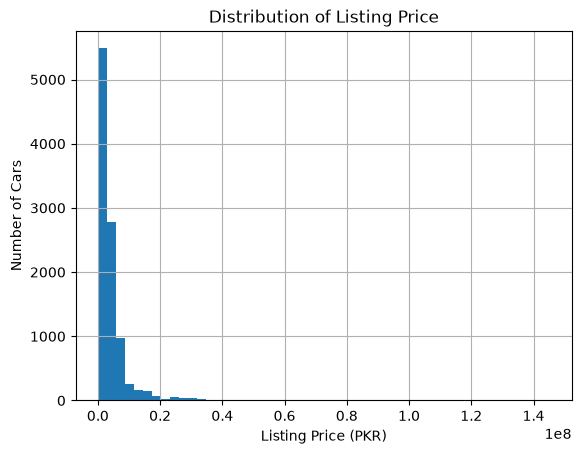

In [25]:
import matplotlib.pyplot as plt

df_final['listingPrice'].hist(bins=50)
plt.xlabel('Listing Price (PKR)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Listing Price')
plt.show()

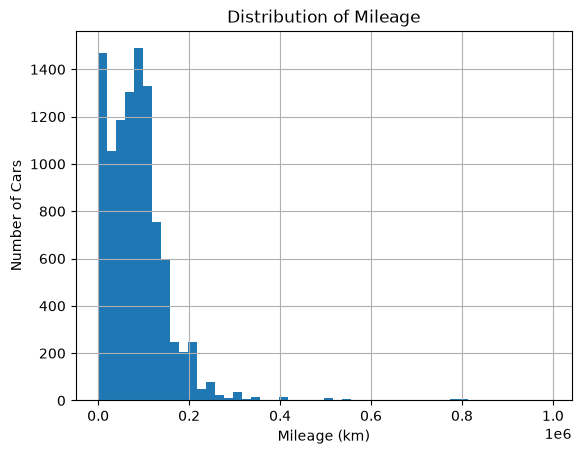

In [26]:
df_final['mileage'].hist(bins=50)
plt.xlabel('Mileage (km)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Mileage')
plt.show()

In [27]:
df_final.sort_values(by='mileage', ascending=False).head(30)

,year,manufacturer,fuelType,transmission,engine,mileage,listingPrice,variant
14147,1984.0,Daihatsu,Petrol,Manual,1000,991555,270000.0,Charade
14958,1980.0,Toyota,Petrol,Manual,1300,990000,340000.0,Corolla
14821,1988.0,Honda,Petrol,Manual,1500,987546,700000.0,Accord
409,2001.0,Honda,Petrol,Manual,1300,982541,690000.0,City
3136,2001.0,Daihatsu,Petrol,Manual,800,910006,550000.0,Cuore
12470,1982.0,Toyota,Petrol,Manual,1300,900000,1100000.0,Corolla
12485,2007.0,Suzuki,Petrol,Manual,1000,900000,970000.0,Alto
5071,1993.0,Toyota,Petrol,Automatic,1300,880000,980000.0,Corolla
2546,1997.0,Honda,Petrol,Manual,1500,875461,810000.0,Civic
14674,2000.0,Suzuki,Petrol,Manual,1000,863254,520000.0,Cultus


In [28]:
(df_final['mileage'] == 1000000).sum()

np.int64(0)

What this shows: rows sharing mileages of 999999, 999998, 999990, and 999000 are almost certainly the same placeholder problem as the exact 1,000,000 rows, just represented with slightly different rounding. Further down the sorted list, values like 980,000 km on a 2018 Suzuki Swift are not placeholders, they are simply impossible given the car's age. Both problems are fixed back in Stage 2 above (the correct stage for anything that changes `df_final`), not here, this block is only the discovery. See `project/notes/NOTES.md` for the full investigation.

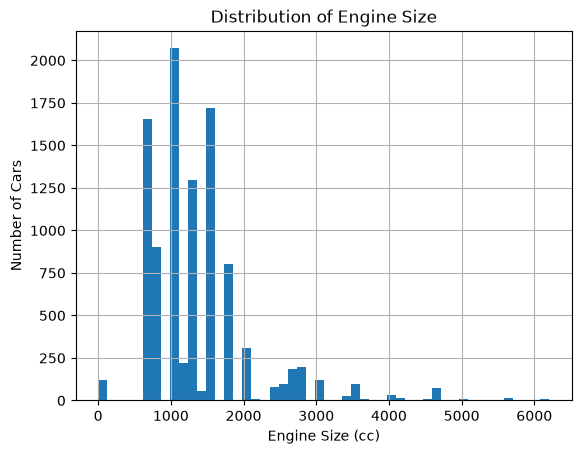

In [29]:
df_final['engine'].hist(bins=50)
plt.xlabel('Engine Size (cc)')
plt.ylabel('Number of Cars')
plt.title('Distribution of Engine Size')
plt.show()

In [30]:
df_final.sort_values(by='engine', ascending=False).head(10)

,year,manufacturer,fuelType,transmission,engine,mileage,listingPrice,variant
1294,2012.0,Mercedes Benz,Petrol,Automatic,6203,20000,27500000.0,Benz S Class
3534,2013.0,Mercedes Benz,Petrol,Automatic,6200,54920,14500000.0,Benz C Class
6611,2012.0,Mercedes Benz,Petrol,Automatic,6200,69000,13700000.0,Benz C Class
7589,2010.0,Mercedes Benz,Petrol,Automatic,6200,87000,13500000.0,Benz C Class
6845,2010.0,Mercedes Benz,Petrol,Automatic,6200,57800,12000000.0,Benz C Class
118,2010.0,Mercedes Benz,Petrol,Automatic,6200,28032,11200000.0,Benz C Class
5825,2010.0,Mercedes Benz,Petrol,Automatic,6200,57000,11800000.0,Benz C Class
5926,2009.0,Mercedes Benz,Petrol,Automatic,6200,50000,12700000.0,Benz C Class
2252,2019.0,Lexus,Petrol,Automatic,5700,15100,71000000.0,LX Series
7863,2019.0,Toyota,Petrol,Automatic,5700,40555,23600000.0,Tundra


In [31]:
(df_final['engine'] > 6000).sum()

np.int64(8)

In [32]:
df_final.sort_values(by='engine', ascending=False).head(17)

,year,manufacturer,fuelType,transmission,engine,mileage,listingPrice,variant
1294,2012.0,Mercedes Benz,Petrol,Automatic,6203,20000,27500000.0,Benz S Class
3534,2013.0,Mercedes Benz,Petrol,Automatic,6200,54920,14500000.0,Benz C Class
6611,2012.0,Mercedes Benz,Petrol,Automatic,6200,69000,13700000.0,Benz C Class
7589,2010.0,Mercedes Benz,Petrol,Automatic,6200,87000,13500000.0,Benz C Class
6845,2010.0,Mercedes Benz,Petrol,Automatic,6200,57800,12000000.0,Benz C Class
118,2010.0,Mercedes Benz,Petrol,Automatic,6200,28032,11200000.0,Benz C Class
5825,2010.0,Mercedes Benz,Petrol,Automatic,6200,57000,11800000.0,Benz C Class
5926,2009.0,Mercedes Benz,Petrol,Automatic,6200,50000,12700000.0,Benz C Class
2252,2019.0,Lexus,Petrol,Automatic,5700,15100,71000000.0,LX Series
7863,2019.0,Toyota,Petrol,Automatic,5700,40555,23600000.0,Tundra


What this shows: the `15000` cluster (Vitara, Civic, Land Cruiser) is a placeholder, the same signature as mileage's problem, an identical, impossible value shared across completely unrelated cars. The Mercedes cluster around 6200-6203cc is the opposite case, a real, consistently repeated spec for a specific high-performance trim, not an error, and was deliberately kept. Everything above 6500cc that wasn't Mercedes is fixed back in Stage 2 above, not here, this block is only the discovery. See `project/notes/NOTES.md` for the full investigation.

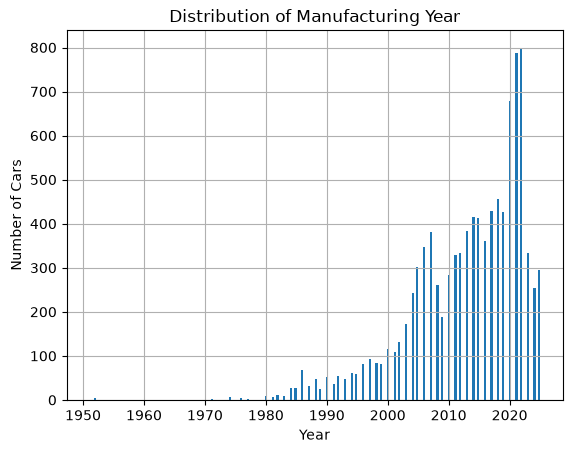

In [33]:
df_final['year'].hist(bins=200)
plt.xlabel('Year')
plt.ylabel('Number of Cars')
plt.title('Distribution of Manufacturing Year')
plt.show()

In [34]:
df_final['year'].min()

np.float64(1951.0)

In [35]:
df_final['year'].max()

np.float64(2025.0)

In [36]:
(df_final['year'] == 1951).sum()

np.int64(1)

What this shows: the shape climbs steadily toward 2020-2023, which makes sense, newer cars are more likely to still be on the road and more likely to be worth listing for resale, while older cars have mostly already been sold, scrapped, or worn out.

Checked the edges directly rather than trusting the shape alone, since mileage and engine both hid real problems that weren't obvious from the histogram: `year.min()` is 1951 and `year.max()` is 2025. Neither is a placeholder. 2025 lines up with when this dataset was scraped (December 2025), and 1951 is a single row (`(df_final['year'] == 1951).sum()` returned 1), a genuine rare vintage listing rather than a repeating fake value like mileage's 1,000,000 or engine's 15,000. No fix needed here.

This completes Univariate analysis. Every column now has a defensible, documented reason for its distribution shape and its edges.

Bivariate (feature vs listingPrice)

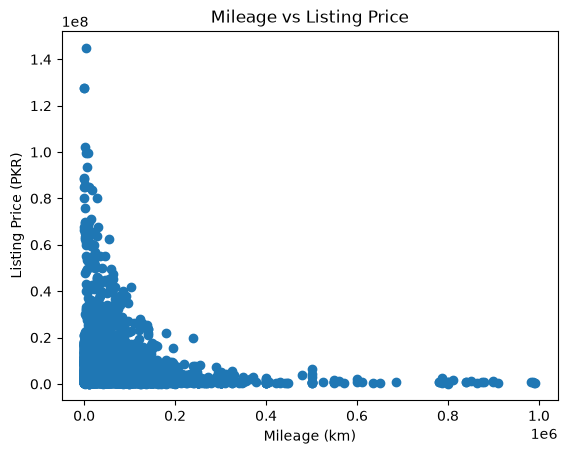

In [37]:
plt.scatter(df_final['mileage'], df_final['listingPrice'])
plt.xlabel('Mileage (km)')
plt.ylabel('Listing Price (PKR)')
plt.title('Mileage vs Listing Price')
plt.show()

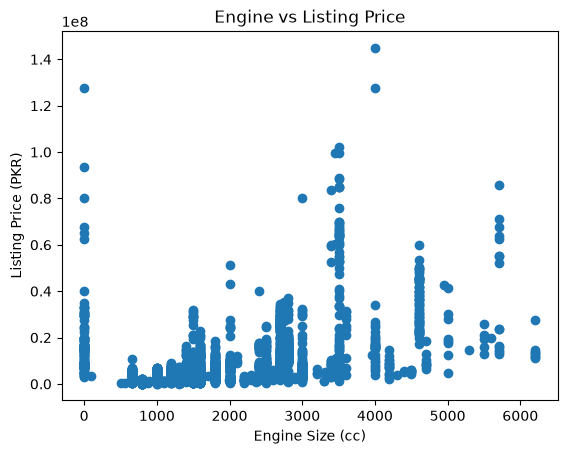

In [38]:
plt.scatter(df_final['engine'], df_final['listingPrice'])
plt.xlabel('Engine Size (cc)')
plt.ylabel('Listing Price (PKR)')
plt.title('Engine vs Listing Price')
plt.show()

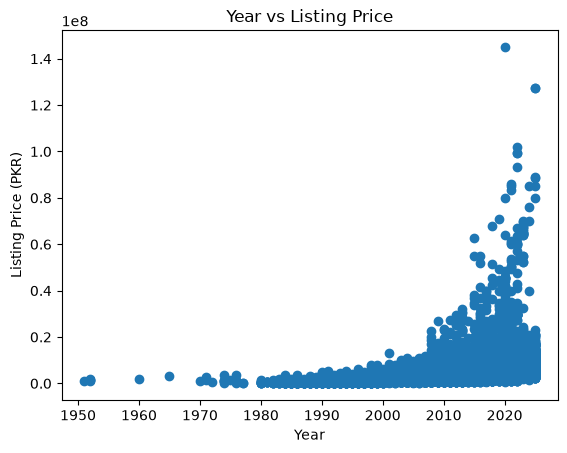

In [39]:
plt.scatter(df_final['year'], df_final['listingPrice'])
plt.xlabel('Year')
plt.ylabel('Listing Price (PKR)')
plt.title('Year vs Listing Price')
plt.show()

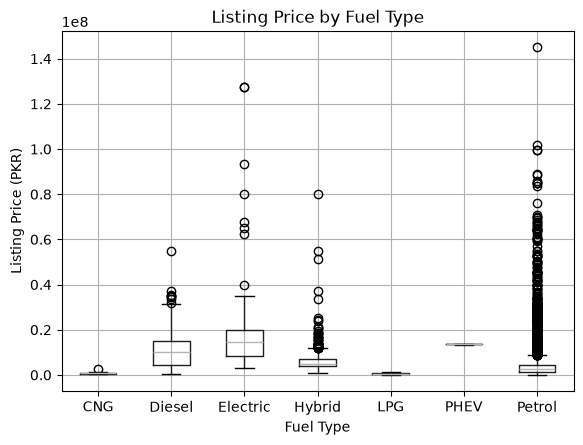

In [40]:
df_final.boxplot(column='listingPrice', by='fuelType')
plt.xlabel('Fuel Type')
plt.ylabel('Listing Price (PKR)')
plt.title('Listing Price by Fuel Type')
plt.suptitle('')
plt.show()

In [41]:
df_final['fuelType'].unique()

<StringArray>
['Hybrid', 'Petrol', 'Diesel', 'CNG', 'Electric', 'LPG', 'PHEV']
Length: 7, dtype: str

What this shows: LPG and Lpg are the same fuel type, just inconsistently capitalized. This is fixed back in Stage 2 above (df_final['fuelType'] = df_final['fuelType'].replace('Lpg', 'LPG')), since it changes df_final itself and Stage 3 cells stay read-only. Re-running the notebook top to bottom applies that fix before this boxplot runs, so the chart above already reflects 7 fuel type categories, not 8.

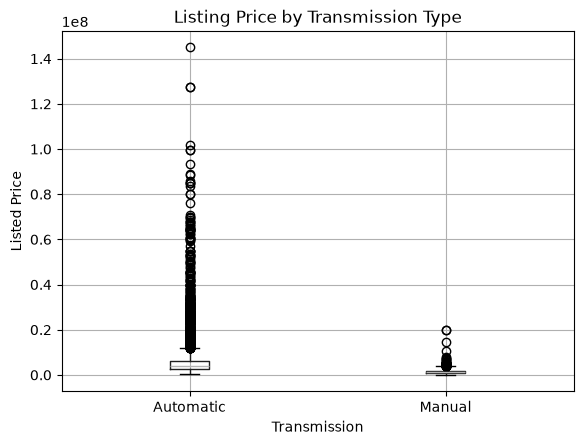

In [42]:
df_final.boxplot(column='listingPrice',by='transmission')
plt.xlabel('Transmission')
plt.ylabel('Listed Price')
plt.title('Listing Price by Transmission Type')
plt.suptitle('')
plt.show()

In [43]:
df_final['transmission'].value_counts()

transmission
Automatic    6611
Manual       3553
Name: count, dtype: int64

In [44]:
df_final.groupby('transmission')['listingPrice'].median()

transmission
Automatic    4000000.0
Manual       1090000.0
Name: listingPrice, dtype: float64

What this shows: Automatic cars have a much higher median listing price (4,000,000) than Manual cars (1,090,000), roughly 3.7x higher, confirming what the boxplot suggested visually. Automatic is also the majority in this dataset (6,611 rows vs 3,553 for Manual), a real 65/35 split, not the dramatic imbalance it first looked like from outlier-dot density alone. This is a genuine market pattern, not a data-quality problem: outliers here are not errors the way mileage's 1,000,000 or engine's 15,000 were, an automatic car priced far above the typical range is very likely a real luxury vehicle, "outlier" in a boxplot just means statistically unusual within its group, not wrong or mispriced. Overall, `transmission` looks like a genuinely useful signal for predicting price.

In [45]:
df_final['manufacturer'].nunique()

58

In [46]:
df_final['variant'].nunique()

349

In [47]:
print(df_final['manufacturer'].value_counts())

manufacturer
Toyota           3002
Suzuki           2871
Honda            1563
Daihatsu          886
Nissan            348
KIA               289
Hyundai           164
Mitsubishi        161
Changan           146
Mercedes Benz     103
Audi               65
Haval              58
MG                 48
Lexus              46
Mazda              40
BMW                35
FAW                33
Peugeot            29
Ford               25
Proton             24
DFSK               20
Chevrolet          20
BYD                18
Subaru             17
Jeep               17
Prince             16
Isuzu              15
Chery              15
JAC                10
Porsche            10
MINI                6
United              6
Range Rover         6
Tesla               6
Deepal              5
Volkswagen          5
Jetour              4
Land Rover          4
Seres               3
BAIC                3
Daewoo              3
Dongfeng            2
Datsun              2
GMC                 1
SsangYong          

In [48]:
print(df_final['variant'].value_counts())


variant
Corolla       925
Alto          737
Civic         726
Cultus        567
City          468
             ... 
CR-V            1
Cressida        1
Charmant        1
Pixis Mega      1
 Mini Bus       1
Name: count, Length: 349, dtype: int64


What this shows: name is fully reconstructable from manufacturer, variant, and year plus a constant "for sale in Karachi" suffix that carries no information (the whole dataset is Karachi listings). It adds nothing that isn't already captured by columns that already exist, so it is dropped entirely rather than one-hot encoded or grouped, fixed back in Stage 2 above, next to the earlier age/year redundancy fix, since it changes df_final and Stage 3 cells stay read-only.

Multivariate

Stage 4: Feature Engineering

Every change here should trace back to something Stage 3 showed you.

Log-transforming listingPrice

Traces back to Stage 1 (listingPrice's mean sitting well above its median, right-skew) and Stage 3 (every Bivariate scatter plot against price showing a curved, non-linear shape rather than a straight line). A log transform compresses large values more aggressively than small ones, treating equal ratios as equal distances rather than equal raw differences, which should pull in the long right tail of expensive cars and straighten the skew. Kept as a new column, log_listingPrice, rather than overwriting the original, so real currency values are still available later for interpreting results.

In [49]:
import numpy as np
df_final['log_listingPrice'] = np.log(df_final['listingPrice'])


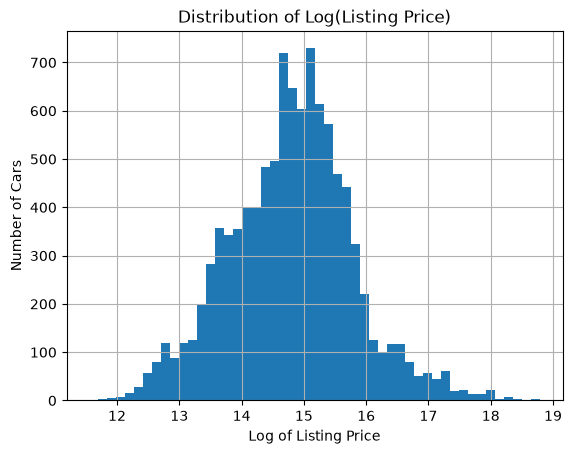

In [50]:
df_final['log_listingPrice'].hist(bins=50)
plt.xlabel('Log of Listing Price')
plt.ylabel('Number of Cars')
plt.title('Distribution of Log(Listing Price)')
plt.show()

Grouping manufacturer and variant into top-N-plus-Other

Traces back to Stage 3 Bivariate, where manufacturer (58 categories) and variant (349 categories) both turned out heavily skewed toward a handful of common values with a long tail of rare, single-listing ones. One-hot encoding either column as-is would create dozens or hundreds of columns the model could never learn anything generalizable from.

manufacturer: kept any brand with at least 100 listings as its own category (Toyota, Suzuki, Honda, Daihatsu, Nissan, KIA, Hyundai, Mitsubishi, Changan, Mercedes Benz), everything else grouped into "Other". Result: 11 categories total, down from 58, with Other holding 631 rows.

variant: same idea, lower threshold (at least 20 listings) since variants are more fragmented than manufacturers to begin with.

Both original columns (manufacturer, variant) are kept alongside the new grouped ones, in case the real brand/model name is needed for reference later.

In [51]:
manufacturer_counts = df_final['manufacturer'].value_counts()
keep_manufacturers = manufacturer_counts[manufacturer_counts >= 100].index
df_final['manufacturer_grouped'] = df_final['manufacturer'].where(
    df_final['manufacturer'].isin(keep_manufacturers), 'Other'
)

variant_counts = df_final['variant'].value_counts()
keep_variants = variant_counts[variant_counts >= 20].index
df_final['variant_grouped'] = df_final['variant'].where(
    df_final['variant'].isin(keep_variants), 'Other'
)

df_final['manufacturer_grouped'].value_counts()

manufacturer_grouped
Toyota           3002
Suzuki           2871
Honda            1563
Daihatsu          886
Other             631
Nissan            348
KIA               289
Hyundai           164
Mitsubishi        161
Changan           146
Mercedes Benz     103
Name: count, dtype: int64

In [52]:
df_final['variant_grouped'].value_counts()

variant_grouped
Other        1293
Corolla       925
Alto          737
Civic         726
Cultus        567
             ... 
Sienta         24
Hiace          24
RX Series      23
Taft           22
Hustler        20
Name: count, Length: 72, dtype: int64

Stage 5: Preprocessing for Modeling

Encoding, scaling, train/test split. Mechanical, not insight-driven. Fit only on train.

Choosing the feature set

Target: log_listingPrice (not listingPrice itself, since that's the raw column it was derived from).

Features: year, mileage, engine (numeric, as-is), fuelType, transmission, manufacturer_grouped, variant_grouped (categorical). manufacturer and variant are excluded in their raw form, manufacturer_grouped and variant_grouped already carry the same information without the unusable long tail of rare categories.

In [53]:
feature_cols = ['year', 'mileage', 'engine', 'fuelType', 'transmission', 'manufacturer_grouped', 'variant_grouped']
X = df_final[feature_cols].copy()
y = df_final['log_listingPrice'].copy()

X = pd.get_dummies(X, columns=['fuelType', 'transmission', 'manufacturer_grouped', 'variant_grouped'], drop_first=True)
X.shape

(10164, 91)

Train/test split, then scaling, in that order

The split has to come before scaling, not after. If we scaled first using statistics (mean, standard deviation) from the whole dataset, information about the test set would leak into how the training data gets prepared, an overly optimistic, dishonest measure of how well the model actually generalizes. Splitting first keeps the test set genuinely unseen.

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((8131, 91), (2033, 91))

Scaling the numeric columns

Only year, mileage, and engine need scaling, the one-hot encoded columns are already 0/1 and don't need it. The scaler is fit only on the training data (fit_transform), then applied to the test data using those same training statistics (transform only, never fit again), same leakage reasoning as the split above: the test set's own mean and spread must never influence how anything gets prepared.

In [55]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['year', 'mileage', 'engine']
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train.head()

,year,mileage,engine,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_LPG,fuelType_PHEV,fuelType_Petrol,transmission_Manual,...,variant_grouped_Sunny,variant_grouped_Surf,variant_grouped_Swift,variant_grouped_Taft,variant_grouped_Tucson,variant_grouped_Vezel,variant_grouped_Vitz,variant_grouped_Wagon R,variant_grouped_Yaris Hatchback,variant_grouped_Yaris Sedan
8376,0.975625,-0.460084,-1.792104,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12756,1.081709,-0.756592,-0.919546,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
14218,-0.509562,8.081814,-0.470046,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
12296,-0.191307,0.186840,-0.470046,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3379,-0.191307,0.725944,-0.734458,False,False,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


Stage 6: Modeling

Baseline first (beat the mean), then multiple linear regression.

Baseline: what if we just guessed the average every time?

Before trusting any real model, there needs to be something concrete to beat. The dumbest possible prediction is to ignore every feature and just guess the average log price for every single car. If our actual model can't beat this, it isn't learning anything useful.

In [56]:
baseline_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

scikit-learn's LinearRegression

The standard, well-tested implementation. Fit on the training data only, predictions made on the untouched test set.

In [57]:
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)
sklearn_pred = sklearn_model.predict(X_test)

Our own MultipleLinearRegression class, side by side

Brought in from learningMultipleLinearRegression.ipynb. It solves for the coefficients directly with the Normal Equation, betas = (X_transpose . X)^-1 . X_transpose . y, rather than scikit-learn's internal solver, but it's aiming at the exact same answer: the line (or in this case, hyperplane) that best fits the training data.

Ran into a real error the first time: `UFuncTypeError: Cannot cast ufunc 'inv' input from dtype('O') to dtype('float64')`. The cause: X_train has a mix of column types under the hood, scaled numeric columns (float64) and one-hot dummy columns (True/False booleans), and calling `.values` on that mix didn't cleanly produce a single numeric array the way it looked like it should, it came out as dtype `object` instead. `np.linalg.inv` refuses to work on an object-dtype array, since it can't guarantee every value is really a plain float underneath.

Fix: explicitly force everything to float before converting to a numpy array, `.astype(float).values` instead of just `.values`. That guarantees True/False become 1.0/0.0 and every column ends up genuinely numeric, not just "probably numeric".

In [58]:
class MultipleLinearRegression:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        # Prepend a column of 1's to X so we can solve for the intercept
        # (beta_0) in the same matrix equation as the feature coefficients.
        X_train = np.insert(X_train, 0, 1, axis=1)

        # Normal Equation: betas = (X^T X)^-1 X^T y
        betas = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self, X_test):
        # y_pred = X . coefficients + intercept
        y_pred = np.dot(X_test, self.coef_) + self.intercept_
        return y_pred

custom_model = MultipleLinearRegression()
custom_model.fit(X_train.astype(float).values, y_train.astype(float).values)
custom_pred = custom_model.predict(X_test.astype(float).values)

A quick sanity check before Stage 7

Both models are solving the same underlying math problem (ordinary least squares), so their coefficients and predictions should come out very close to identical, small floating-point differences aside. Comparing the intercepts directly is a fast way to confirm both implementations agree before trusting either one's evaluation numbers in Stage 7.

In [59]:
print("sklearn intercept:", sklearn_model.intercept_)
print("custom intercept:", custom_model.intercept_)

sklearn intercept: 13.988732107757304
custom intercept: 13.9887321078732


Stage 7: Evaluation & Iteration

MAE / RMSE / R² / Adjusted R² on the test set. Residuals. What's next.

Manual metrics first, same logic as learningSimpleLinearRegression.ipynb

Same three steps as before: raw error (actual minus predicted), then absolute error averaged for MAE, then squared error averaged and square-rooted for RMSE. Doing this by hand for all three predictions (baseline, sklearn, and our own class) before trusting any library function.

In [ ]:
def manual_metrics(y_true, y_pred, name):
    error = y_true - y_pred
    mae = np.abs(error).mean()
    mse = (error ** 2).mean()
    rmse = mse ** 0.5
    print(f"{name}: MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}")
    return mae, mse, rmse

manual_metrics(y_test, baseline_pred, "Baseline (predict the mean)")
manual_metrics(y_test, sklearn_pred, "scikit-learn")
manual_metrics(y_test, custom_pred, "Our own class")

Double-checking with scikit-learn's functions

Same numbers should come back, just computed by a trusted library instead of by hand. If these don't match the manual numbers above, something in the manual formula is wrong.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

for name, pred in [("Baseline", baseline_pred), ("scikit-learn", sklearn_pred), ("Our own class", custom_pred)]:
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, pred)
    print(f"{name}: MAE={mae:.4f}  MSE={mse:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")

R² and Adjusted R²

R² answers: how much better is this model than just guessing the average every time? 1.0 is a perfect fit, 0 means no better than the baseline, negative means worse than just guessing the mean.

Adjusted R² penalizes a model for having a lot of features (we have 91), since R² alone can look artificially better just by adding more columns, even useless ones. This matters here specifically because of the manufacturer/variant_grouped columns inflating our feature count.

In [ ]:
n = len(y_test)
k = X_test.shape[1]

for name, pred in [("scikit-learn", sklearn_pred), ("Our own class", custom_pred)]:
    r2 = r2_score(y_test, pred)
    adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - 1 - k)
    print(f"{name}: R2={r2:.4f}  Adjusted R2={adjusted_r2:.4f}")

Residual plot

A residual is the leftover error, actual minus predicted, for every row. Plotted against the predicted value, a healthy model shows residuals scattered randomly around zero with no visible pattern. A pattern (a curve, a funnel shape, a slope) would mean the model is systematically wrong in some predictable way, which the raw R² number alone wouldn't reveal.

In [ ]:
residuals = y_test - sklearn_pred
plt.scatter(sklearn_pred, residuals, s=10, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(listingPrice)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()